# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from cellpose import models, plot
from skimage import measure
from skimage.measure import regionprops
import cv2
from scipy.spatial import cKDTree

# Upload Image

In [3]:
IMAGE_PATH = "./Images/control/50000/Sample 1_05.tif"   

original_image = np.array(Image.open(IMAGE_PATH).convert("L"))

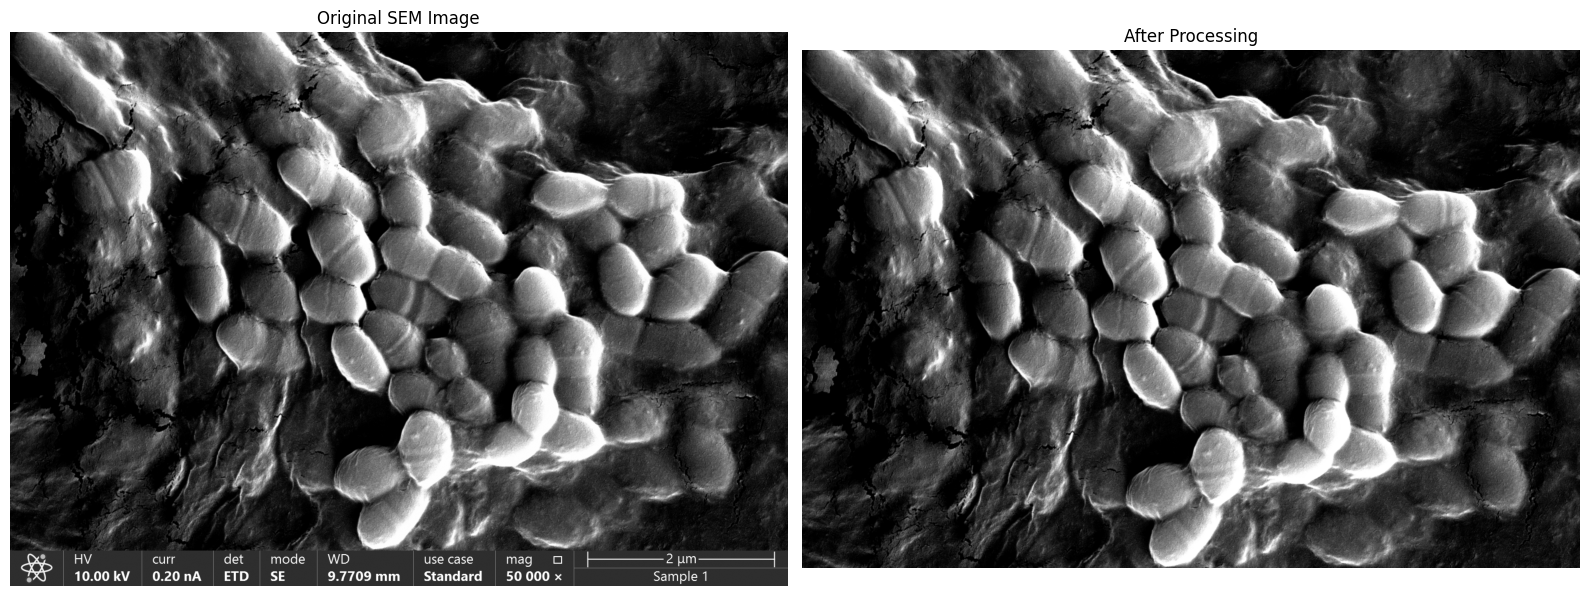

In [4]:
height, width = original_image.shape

image = original_image[:height - 70, :]

# Display both original and cropped for comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Original SEM Image')
axes[0].axis('off')

axes[1].imshow(image, cmap='gray')
axes[1].set_title('After Processing')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Segmentation

Detected 24 bacteria


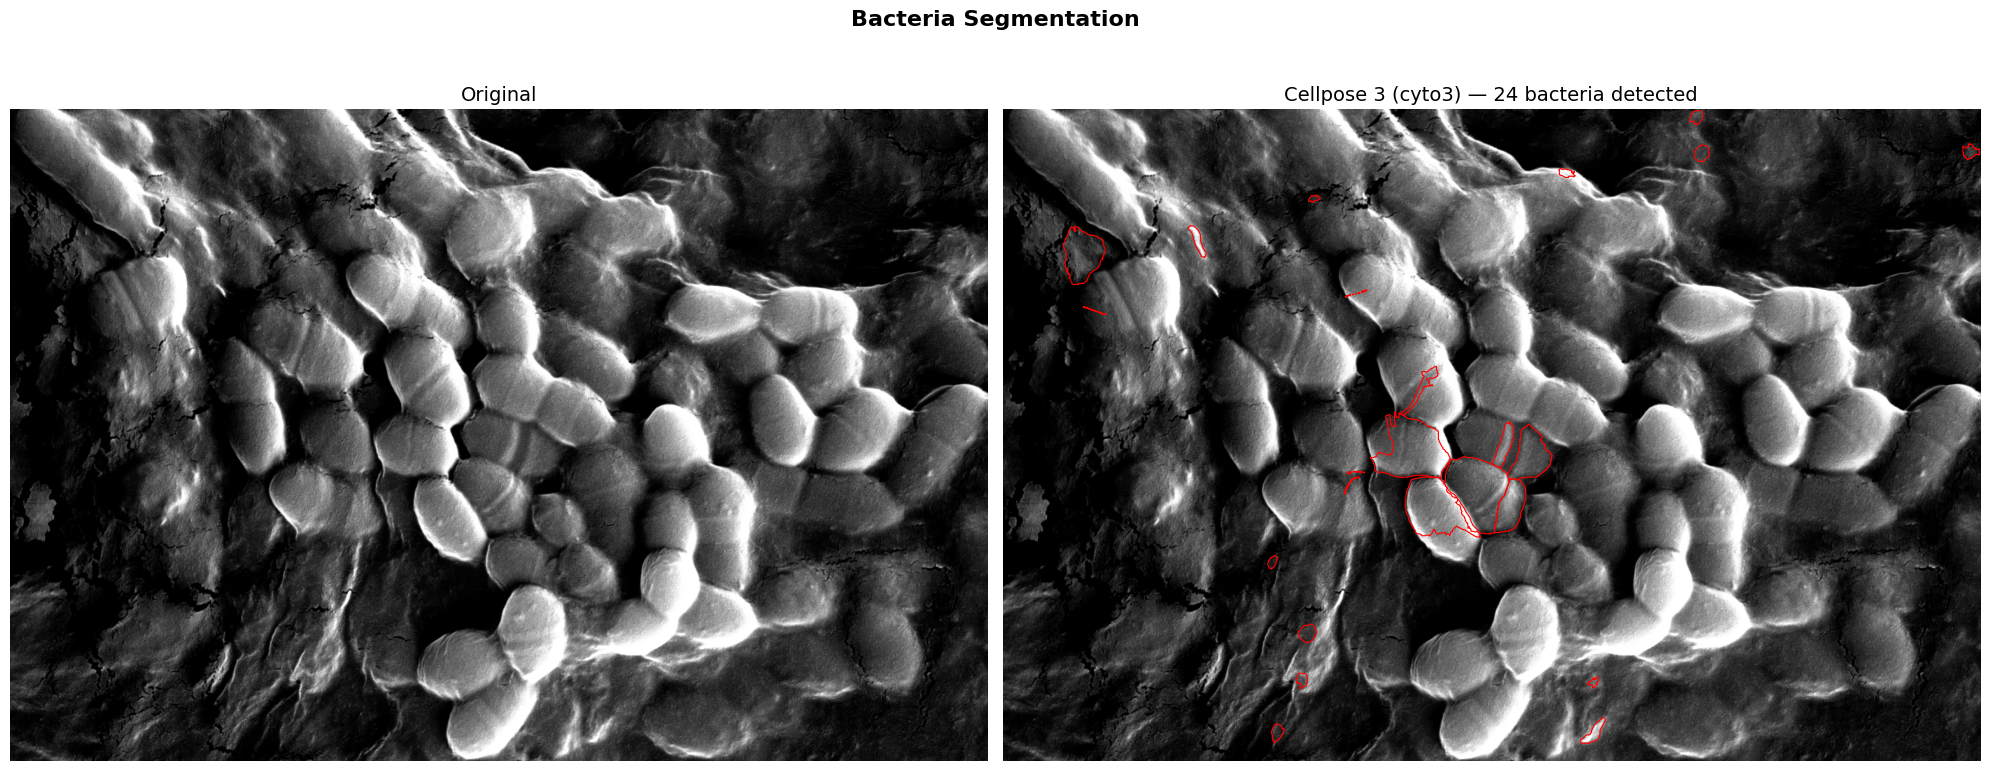

In [7]:
MODEL_TYPE   = "cyto3"  
FLOW_THRESH  = 0.7      
CELLPROB_THRESH = 0.0    

def run_segmentation(img):
 
    model = models.Cellpose(model_type="cyto3", gpu=False)
    masks, _, _, _ = model.eval(
        img,
        channels=[0, 0],
        flow_threshold=FLOW_THRESH,
        cellprob_threshold=CELLPROB_THRESH,
    )
 
    print(f"Detected {masks.max()} bacteria")
    return masks
 
def visualize(img, masks):
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
 
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original", fontsize=14)
    axes[0].axis("off")
 
    axes[1].imshow(img, cmap="gray")
    for region in measure.regionprops(masks):
        cell_mask = (masks == region.label).astype(np.uint8)
        contours = measure.find_contours(cell_mask, 0.5)
        for contour in contours:
            axes[1].plot(contour[:, 1], contour[:, 0], linewidth=0.8, color="red")
 
    n_cells = masks.max()
    axes[1].set_title(f"Cellpose 3 (cyto3) — {n_cells} bacteria detected", fontsize=14)
    axes[1].axis("off")
 
    plt.suptitle("Bacteria Segmentation", fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show() 

masks = run_segmentation(image)
visualize(image, masks)

# Make List

In [30]:
def extract_bacteria_features(mask: np.ndarray) -> list[dict]:
    """Extract features for all bacteria in mask."""
    bacteria_list = []
    min_area = 1000
    
    for prop in regionprops(mask):
        if prop.area < min_area:
            continue
        
        individual_mask = (mask == prop.label).astype(np.uint8)
        contours, _ = cv2.findContours(individual_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if len(contours) == 0 or len(contours[0]) < 5:
            continue
        
        contour = contours[0]
        major_px = prop.major_axis_length / 2
        minor_px = prop.minor_axis_length / 2

        ratio = 5.0 / 370
        
        bacteria_list.append({
            'bacteria_id': prop.label,
            'contour': contour,
            'center': (int(prop.centroid[1]), int(prop.centroid[0])),
            'major_radius_pixels': major_px,
            'minor_radius_pixels': minor_px,
            'major_radius': major_px * ratio,
            'minor_radius': minor_px * ratio,
            'area': prop.area * ratio * ratio,
            'aspect_ratio': major_px / minor_px if minor_px > 0 else float('inf'),
            })
    
    return bacteria_list

bacteria_list = extract_bacteria_features(masks)

In [33]:
def get_perimeter_distance(b1: dict, b2: dict) -> float:
    """Calculate minimum distance between bacteria contours."""
    p1 = b1['contour'].reshape(-1, 2).astype(float)
    p2 = b2['contour'].reshape(-1, 2).astype(float)
    
    tree = cKDTree(p2)
    distances, _ = tree.query(p1)
    return float(np.min(distances))


def find_neighbors(bacteria_list: list[dict], threshold: float) -> list[dict]:
    """Find neighbors for each bacterium using spatial indexing."""
    if not bacteria_list:
        return bacteria_list
    
    centers = [b['center'] for b in bacteria_list]
    max_radius = max(b['major_radius_pixels'] for b in bacteria_list)
    tree = cKDTree(centers)
    
    for i, bacteria in enumerate(bacteria_list):
        search_radius = bacteria['major_radius_pixels'] + max_radius + threshold
        candidates = tree.query_ball_point(bacteria['center'], search_radius)
        
        neighbors = [
            j for j in candidates
            if j != i and get_perimeter_distance(bacteria, bacteria_list[j]) < threshold
        ]
        
        bacteria['neighbor_count'] = len(neighbors)
        bacteria['neighbors_list'] = neighbors
    
    return bacteria_list


bacteria_list = find_neighbors(bacteria_list, 5)

In [34]:
def filter_background_bacteria(bacteria_with_orientations, min_area_compare=0.7):
    """Filter bacteria that are significantly smaller than average OR their neighbors."""
    if not bacteria_with_orientations:
        return [], {'total': 0, 'filtered_global': 0, 'filtered_local': 0, 'kept': 0}
    
    # Pre-compute all areas
    areas = {idx: cv2.contourArea(b['contour']) 
             for idx, b in enumerate(bacteria_with_orientations)}
    
    filtered = []
    filtered_global_count = 0
    filtered_local_count = 0
    
    for idx, bacteria in enumerate(bacteria_with_orientations):
        bacteria_area = areas[idx]
        
        # Check: smaller than neighbors?
        neighbors = bacteria.get('neighbors_list', [])
        if neighbors:
            neighbor_areas = [areas[n] for n in neighbors if n in areas]
            if neighbor_areas:
                avg_neighbor_area = np.mean(neighbor_areas)
                if bacteria_area < min_area_compare * avg_neighbor_area:
                    filtered_local_count += 1
                    continue  # Filter out
        
        # Passed both checks → keep
        filtered.append(bacteria)
    
    stats = {
        'total': len(bacteria_with_orientations),
        'filtered_global': filtered_global_count,
        'filtered_local': filtered_local_count,
        'kept': len(filtered)
    }
    
    return filtered, stats

filtered_bacteria, filter_stats = filter_background_bacteria(
        bacteria_list, 
        min_area_compare=0.7
    )

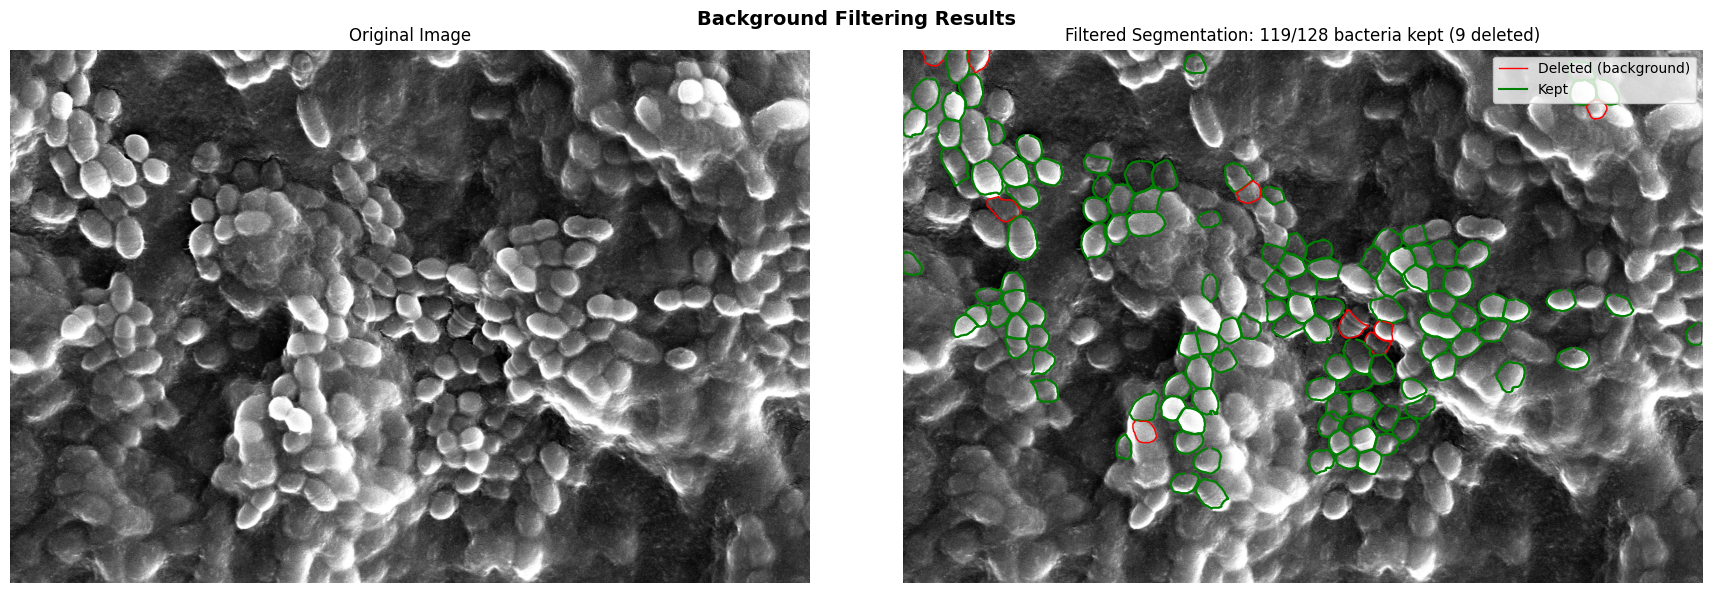

In [35]:
# Create the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Original image
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image', fontsize=12)
axes[0].axis('off')

# Segmentation with contours - green for kept, red for deleted
axes[1].imshow(image, cmap='gray')

# Initialize these BEFORE the loop
kept_plotted = False
deleted_plotted = False

# Use object identity instead of bacteria_id
kept_bacteria_set = set(id(b) for b in filtered_bacteria)

for bacteria in bacteria_list:
    contour = bacteria['contour'].squeeze()
    
    if id(bacteria) in kept_bacteria_set:
        color = 'g'
        linewidth = 1.5
        label = 'Kept' if not kept_plotted else None
        kept_plotted = True
    else:
        color = 'r'
        linewidth = 1
        label = 'Deleted (background)' if not deleted_plotted else None
        deleted_plotted = True
    
    axes[1].plot(contour[:, 0], contour[:, 1], color=color, linewidth=linewidth, label=label)

n_bacteria = len(bacteria_list)
axes[1].set_title(f'Filtered Segmentation: {len(filtered_bacteria)}/{n_bacteria} bacteria kept ({n_bacteria - len(filtered_bacteria)} deleted)', 
                  fontsize=12)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].axis('off')

plt.suptitle('Background Filtering Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()